### Khai báo thư viện ảnh và kiểm tra OpenCv đọc ảnh

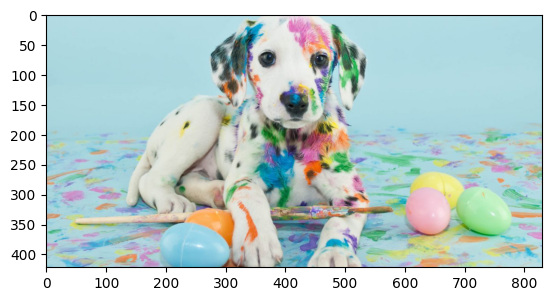

In [5]:
import cv2
import matplotlib.pyplot as plt

# Kiểm tra opencv đọc ảnh và đặt ảnh cho đúng hiển thị ban đầu
img = cv2.imread('./dog.png')
if img is not None:
    # Đổi không gian màu từ BGR sang RGB
    img = img[:, :, ::-1]
    plt.imshow(img)
    plt.show()
else:
    print("Không tìm thấy ảnh dog.png ở thư mục hiện tại")

### 1. Thực hành xử lý ảnh trong miền tần số:
- **Fast Fourier Transform (FFT) algorithm để phát hiện ảnh mờ.**

In [6]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

# Đọc bức ảnh và đưa về float32
img = cv2.imread('dog.png', 0)
if img is not None:
    img_float32 = np.float32(img)
    
    # Đưa ảnh về dạng số phức, và dùng fft có sẵn trong numpy để biến đổi 
    # để được biên độ của các sóng với các tần số khác nhau
    dft = cv2.dft(img_float32, flags = cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    
    # Đưa về thang log, rồi khuếch đại lên 20 lần để vẽ. 
    # Đưa về thang log để biên độ chênh lệch giữa các sóng được giảm xuống.
    magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]))
else:
    print("Lỗi không mở được ảnh dog.png")

### 2. Sử dụng đoạn code sau cho DFT, trình bày ý nghĩa của từng dòng lệnh.

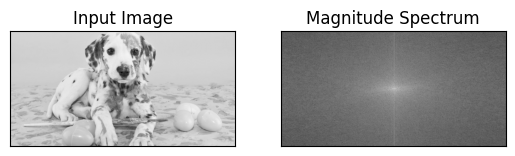

In [7]:
if img is not None:
    plt.subplot(121), plt.imshow(img, cmap = 'gray')
    plt.title('Input Image'), plt.xticks([]), plt.yticks([])
    
    plt.subplot(122), plt.imshow(magnitude_spectrum, cmap = 'gray')
    plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
    
    plt.show()

**Giải thích ý nghĩa của từng dòng lệnh:**
- `plt.subplot(121)`: Tạo ra một lưới hình ảnh gồm 1 hàng và 2 cột để chứa đồ thị. Đồ thị chuẩn bị vẽ sẽ được đặt ở vị trí số 1 (bên trái) trong lưới này.
- `plt.imshow(img, cmap = 'gray')`: Vẽ ma trận hình ảnh `img` dưới chuẩn bản đồ màu xám (grayscale).
- `plt.title('Input Image')`: Đặt tên tiêu đề (title) cho đồ thị đầu tiên này là 'Input Image'.
- `plt.xticks([]), plt.yticks([])`: Ẩn đi các vạch chia toạ độ trên đoạn trục x và y để hiển thị nhìn gọn gàng và giống một bức ảnh thuần tuý thay vì đồ thị có số đo.
- `plt.subplot(122)`: Chọn vị trí tiếp theo (vị trí số 2, bên phải lưới) để làm nơi vẽ đồ thị thứ hai.
- `plt.imshow(magnitude_spectrum, cmap = 'gray')`: Gọi lệnh vẽ phổ biên độ sóng `magnitude_spectrum` đo được sau biến đổi Fourier, cũng ở dạng màu xám.
- `plt.title('Magnitude Spectrum')`: Đặt tên tiêu đề cho ảnh thứ hai là 'Magnitude Spectrum'.
- `plt.show()`: Render và biểu diễn toàn bộ các đồ thị đã được setup xong ra giao diện.

### 3. Sử dụng Fast Fourier Transform (FFT) Magnitude algorithm để phát hiện ảnh mờ

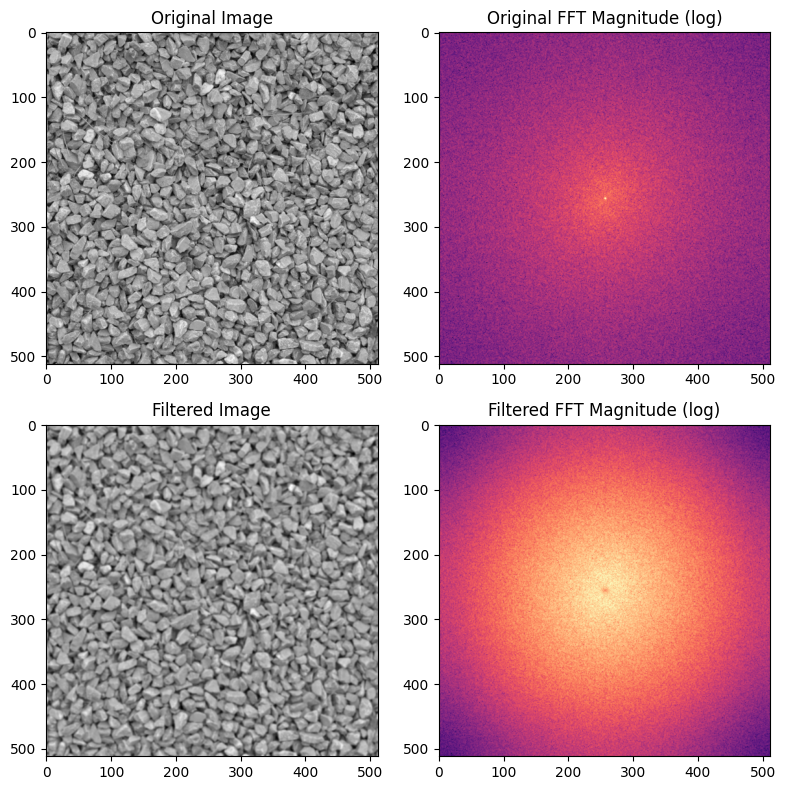

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.data import gravel
from skimage.filters import difference_of_gaussians, window
from scipy.fft import fftn, fftshift

image = gravel()
wimage = image * window('hann', image.shape)  # window image to improve FFT
filtered_image = difference_of_gaussians(image, 1, 12)
filtered_wimage = filtered_image * window('hann', image.shape)

im_f_mag = fftshift(np.abs(fftn(wimage)))
fim_f_mag = fftshift(np.abs(fftn(filtered_wimage)))

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))
ax[0, 0].imshow(image, cmap='gray')
ax[0, 0].set_title('Original Image')

ax[0, 1].imshow(np.log(im_f_mag), cmap='magma')
ax[0, 1].set_title('Original FFT Magnitude (log)')

ax[1, 0].imshow(filtered_image, cmap='gray')
ax[1, 0].set_title('Filtered Image')

ax[1, 1].imshow(np.log(fim_f_mag), cmap='magma')
ax[1, 1].set_title('Filtered FFT Magnitude (log)')

plt.tight_layout()
plt.show()